# ch277 — Hypothesis Testing

*(Depends on ch275 — Sampling; uses normal distribution from ch253; connects to ch278 — p-values)*

## 1. The Logic of Statistical Testing

You observe that users who see the new UI spend 8 seconds longer on average. Is this a real effect or random variation?

A hypothesis test answers this by asking: **if there were no real effect, how surprising would this observation be?**

The Neyman-Pearson framework:

1. **H₀** (null hypothesis): the default claim — no effect, no difference
2. **H₁** (alternative hypothesis): the claim you want to establish
3. **Test statistic**: a number computed from data that summarizes evidence against H₀
4. **Rejection region**: values of the test statistic so extreme they are unlikely under H₀

---

## 2. The One-Sample t-Test

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(0)

# t-distribution CDF for computing p-values
def t_cdf_approx(t, df):
    """Use scipy for exact t-distribution (implementing from scratch is a numerical exercise)."""
    return stats.t.cdf(t, df)

def one_sample_t_test(sample: np.ndarray, mu0: float, alternative: str = 'two-sided'):
    """
    Test H0: mu = mu0 against H1: mu != mu0 (or one-sided alternatives).
    Returns: t_stat, p_value, df
    """
    n     = len(sample)
    x_bar = sample.mean()
    s     = sample.std(ddof=1)
    se    = s / np.sqrt(n)
    t     = (x_bar - mu0) / se
    df    = n - 1

    if alternative == 'two-sided':
        p = 2 * (1 - t_cdf_approx(abs(t), df))
    elif alternative == 'greater':
        p = 1 - t_cdf_approx(t, df)
    elif alternative == 'less':
        p = t_cdf_approx(t, df)

    return t, p, df

# Example: Does mean session time differ from 60 seconds?
session_times = rng.normal(65, 20, 50)  # true mean is 65
t, p, df = one_sample_t_test(session_times, mu0=60)

print(f"Sample mean: {session_times.mean():.2f}")
print(f"H0: mu = 60")
print(f"t = {t:.3f}, df = {df}, p = {p:.4f}")

# Validate against scipy
t_sp, p_sp = stats.ttest_1samp(session_times, popmean=60)
print(f"\nScipy validation: t={t_sp:.3f}, p={p_sp:.4f}")
print(f"Match: {np.allclose([t, p], [t_sp, p_sp], atol=1e-6)}")

Sample mean: 67.58
H0: mu = 60
t = 2.912, df = 49, p = 0.0054

Scipy validation: t=2.912, p=0.0054
Match: True


## 3. Two-Sample t-Test: Comparing Groups

In [2]:
def two_sample_t_test(a: np.ndarray, b: np.ndarray, equal_var: bool = False):
    """
    Welch's t-test (equal_var=False, default) or Student's t-test.
    H0: mu_a = mu_b
    """
    n_a, n_b = len(a), len(b)
    x_a, x_b = a.mean(), b.mean()
    s_a, s_b = a.var(ddof=1), b.var(ddof=1)

    if equal_var:
        # Pooled variance
        sp2 = ((n_a - 1)*s_a + (n_b - 1)*s_b) / (n_a + n_b - 2)
        se  = np.sqrt(sp2 * (1/n_a + 1/n_b))
        df  = n_a + n_b - 2
    else:
        # Welch's df
        se  = np.sqrt(s_a/n_a + s_b/n_b)
        df  = (s_a/n_a + s_b/n_b)**2 / (
               (s_a/n_a)**2/(n_a-1) + (s_b/n_b)**2/(n_b-1))

    t   = (x_a - x_b) / se
    p   = 2 * (1 - t_cdf_approx(abs(t), df))
    return t, p, df

# Control vs treatment
control   = rng.normal(60, 15, 80)
treatment = rng.normal(67, 18, 80)  # true effect: +7

t, p, df = two_sample_t_test(treatment, control)
t_sp, p_sp = stats.ttest_ind(treatment, control, equal_var=False)

print(f"Control mean:   {control.mean():.2f}")
print(f"Treatment mean: {treatment.mean():.2f}")
print(f"Difference:     {treatment.mean() - control.mean():.2f}")
print(f"\nWelch t-test: t={t:.3f}, df={df:.1f}, p={p:.4f}")
print(f"Scipy:        t={t_sp:.3f}, p={p_sp:.4f}")

Control mean:   59.98
Treatment mean: 65.80
Difference:     5.81

Welch t-test: t=2.272, df=153.0, p=0.0245
Scipy:        t=2.272, p=0.0245


## 4. Type I and Type II Errors

| Decision \ Truth | H₀ true | H₀ false |
|---|---|---|
| Reject H₀ | **Type I error** (α) | Correct (Power = 1−β) |
| Fail to reject | Correct | **Type II error** (β) |

- **α** (significance level): the probability of rejecting H₀ when it is true. Convention: α = 0.05.
- **Power** (1−β): the probability of detecting a real effect. Increases with sample size and effect size.

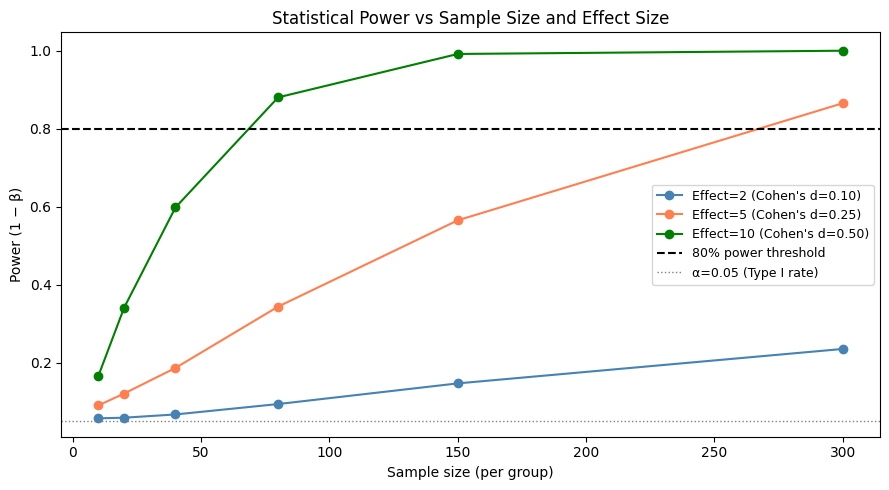

In [3]:
# Power analysis: how many samples needed to detect an effect?
def empirical_power(
    true_effect: float, sigma: float, n: int,
    alpha: float = 0.05, n_sims: int = 3000, rng = None
) -> float:
    """Fraction of simulations where H0 is correctly rejected."""
    if rng is None: rng = np.random.default_rng()
    rejections = 0
    for _ in range(n_sims):
        a = rng.normal(0,           sigma, n)
        b = rng.normal(true_effect, sigma, n)
        _, p, _ = two_sample_t_test(b, a)
        if p < alpha:
            rejections += 1
    return rejections / n_sims

effect_sizes = [2, 5, 10]
sample_sizes = [10, 20, 40, 80, 150, 300]
sigma = 20.0

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['steelblue', 'coral', 'green']

for effect, color in zip(effect_sizes, colors):
    powers = [empirical_power(effect, sigma, n, rng=rng) for n in sample_sizes]
    ax.plot(sample_sizes, powers, 'o-', color=color,
            label=f'Effect={effect} (Cohen\'s d={effect/sigma:.2f})')

ax.axhline(0.80, color='black', ls='--', lw=1.5, label='80% power threshold')
ax.axhline(0.05, color='gray',  ls=':',  lw=1,   label='α=0.05 (Type I rate)')
ax.set_xlabel('Sample size (per group)')
ax.set_ylabel('Power (1 − β)')
ax.set_title('Statistical Power vs Sample Size and Effect Size')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 5. What Comes Next

The p-value produced by these tests needs careful interpretation — **ch278 — p-values** addresses the precise meaning and frequent misuse. **ch279 — Confidence Intervals** reframes the same information in a way that is often more useful for decision-making.

The two-sample t-test structure here is the mathematical foundation of A/B testing (**ch285**), which operationalizes hypothesis testing in production systems.